In [ ]:
import logging

import torch

import specter
from specter.config import load_config, parse_scalar_or_range
from specter.image import normalize_particles
from specter.imagegenerator import ImageGenerator
from specter.memory import resolve_batchsize
from specter.pdb import PDB
from specter.plots import plot3d, plot_particle_stack
from specter.potential import PotentialBuilder
from specter.progress import track
from specter.io import extract_parameters_from_csfile
from specter.ice import IceBank, RandomIcemaker

import mrcfile

%load_ext autoreload
%autoreload 2

In [2]:
specter.set_verbosity(logging.INFO)

## Load config

All of the parameters that control the simulation (except those supplied by the .cs file — pixel size, voltage, alpha, defocus, translations) live in [`simulate-particles-from-csfile.toml`](./simulate-particles-from-csfile.toml), loaded below via `load_config(...)` — **edit that file, not this notebook**, to change what gets generated.

In [3]:
config = load_config("simulate-particles-from-csfile.toml")

## Specify .cs from CryoSPARC Job that contains rotations and aberrations

In [4]:
n_particles = config.n_particles  # set to None for all.
(
    voltage_kv,
    pixel_size,
    alpha,
    rotations,
    translations_A,
    ctf_params,
    scale,
    anisomag,
    indices,
    split,
) = extract_parameters_from_csfile(config.cs_path, n_particles=n_particles)
rotations.shape

torch.Size([10, 4])

## Generate particle scattering potential

In [5]:
# fetch pdb file
# config.assembly: True fetches assembly, False fetches subunit, int fetches a specific assembly #
pdb = PDB(config.pdb_code, assembly=config.assembly, savefolder=config.pdb_savefolder)
# pdb = PDB(
#     "/scratch/loh/joel/czii/russo-scattering-factors/simulated_dataset/8el9_sim_1_cat_params.cif"
# )

Assemblies available: 1
6bdf: Fetching default Biological Assembly 1
File already exists: /mnt/cbis/home/e0788253/czii/specter/pdb-data/6bdf-assembly1.cif, skip fetching.


Extracting atom coordinates and element: 0it [00:00, ?it/s]

In [6]:
# Samples 3D scattering potential onto specified grid
# Potential-building always runs on CPU, independent of config.device.
pb = PotentialBuilder(config.num_pixels, pixel_size.item(), pdb.atomic_numbers)

In [7]:
with torch.no_grad():
    V = pb(pdb.coordinates).clone()

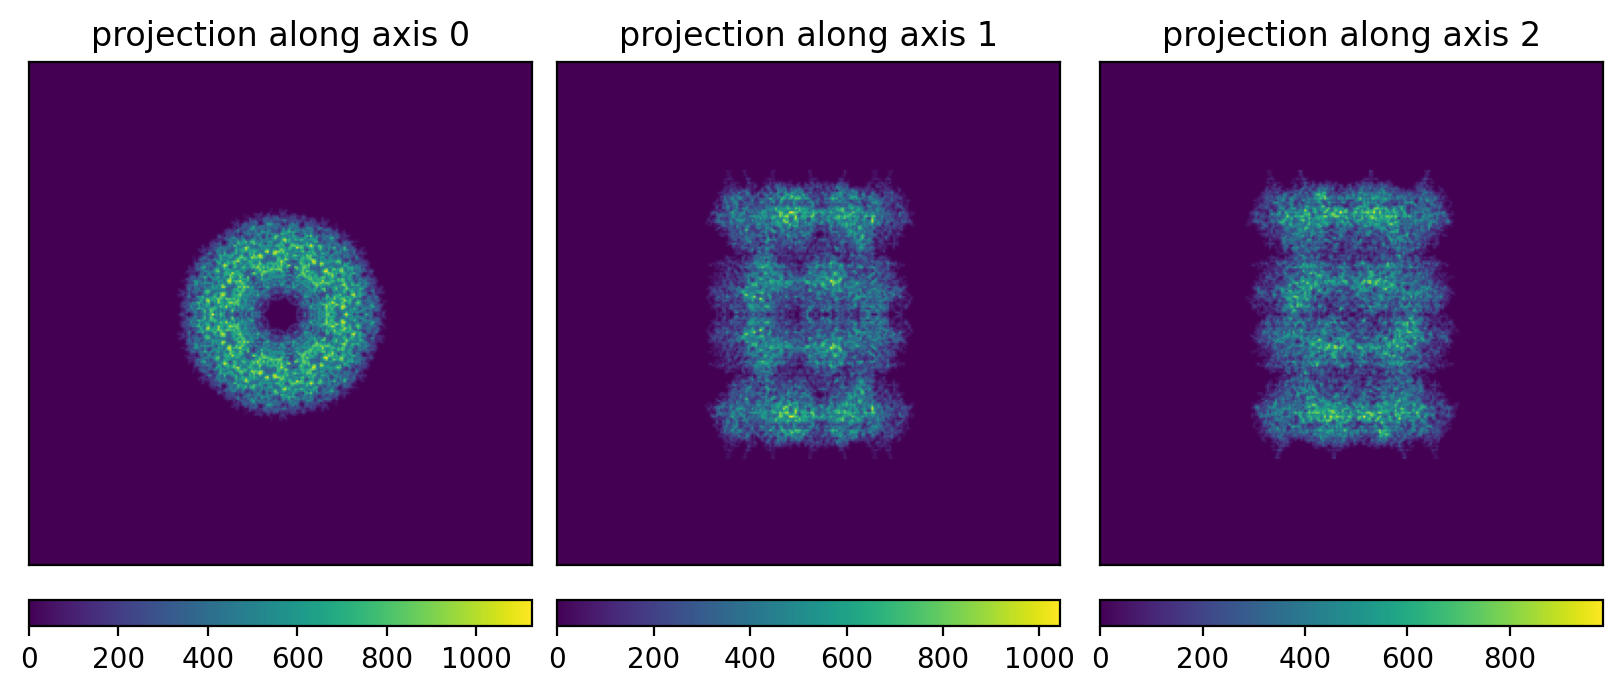

In [8]:
plot3d(V)

## Generate particles
Note: adjust ```coincidence_radius``` to match the contrast of your simulated images to the experiments.

In [9]:
# n_particles = len(rotations)  # number of particles
device = config.device  # choose cpu if you run out of cuda memory.

In [10]:
# Build the icemaker once — move to GPU before generating
# ice_model:
#   'random' : fast, worst accuracy. RandomIcemaker.
#   'gd'     : gradient descent, cached. slower, highest accuracy. IceBank.
#   'none'   : disable ice
ice_model = None if config.ice_model == "none" else config.ice_model
bank = None
if ice_model == "random":
    n_ice = min(config.num_pixels, int(256 / pixel_size.item()))
    bank = RandomIcemaker(dx=pixel_size.item(), n=n_ice)
elif ice_model == "gd":
    bank = IceBank(cache_dir=config.ice_cache_dir)
if bank is not None:
    bank = bank.to(device)

In [ ]:
noise_model = None if config.noise_model == "none" else config.noise_model
detector_model = None if config.detector_model == "none" else config.detector_model

# Coincidence radius in pixels.
# Higher values suppress lower spatial frequencies.
# Set to 0 to recover default Poisson behaviour.
coincidence_radius, _ = parse_scalar_or_range(config.coincidence_radius)

crowd_min_distance = (
    config.crowd_min_distance
    if config.crowd_min_distance is not None
    else pdb.max_diameter
)

dose_low, _ = parse_scalar_or_range(config.dose)
num_frames = config.num_frames if config.num_frames is not None else int(dose_low)

cc_angstrom = config.cc * 1e7 if config.cc is not None else None  # mm -> Å

potential_scale_low, _ = parse_scalar_or_range(config.potential_scale)

model = ImageGenerator(
    V,
    pixel_size.item(),
    rotations,
    translations_A,
    ctf_params,
    voltage_kv,
    dose_low,
    ice_thickness=config.ice_thickness,
    scattering_model=config.scattering_model,
    aberration_model=config.aberration_model,
    noise_model=noise_model,
    klim=None,
    ews_curvature_sign="positive",
    alpha=alpha,
    crowd_min_distance=crowd_min_distance,
    crowd_max_distance_z=config.crowd_max_distance_z,
    pad_fft=config.pad_fft,
    detector_model=detector_model,
    verbose=False,
    coincidence_radius=coincidence_radius,
    num_frames=num_frames,
    icemaker=bank,
    potential_scale=potential_scale_low,
    bfactor=config.bfactor,
    convergence_angle=config.convergence_angle,
    cc=cc_angstrom,
    energy_spread=config.energy_spread,
    deltaV_V=config.deltaV_V,
    deltaI_I=config.deltaI_I,
    dose_envelope=config.dose_envelope,
).to(device)

In [12]:
# config.batchsize may be an int or "auto"; resolve_batchsize turns "auto"
# into the largest batch that fits the memory free on `device` right now.
batchsize = resolve_batchsize(
    config.batchsize,
    config.num_pixels,
    model.nz,
    model.pad_nxy,
    device,
    n_particles=len(rotations),
)

idx = torch.arange(len(rotations))
images = []
with torch.no_grad():
    for i in track(
        range(0, len(rotations), batchsize), description="Generating images"
    ):
        image = model(idx[i : i + batchsize])
        images.append(image.detach().cpu())

images = torch.concat(images, dim=0)
images.shape

Generating images:   0%|          | 0/2 [00:00<?, ?it/s]

Rotating duplicates and insert into micrograph:   0%|          | 0/9 [00:00<?, ?it/s]

Rotating duplicates and insert into micrograph:   0%|          | 0/11 [00:00<?, ?it/s]

Rotating duplicates and insert into micrograph:   0%|          | 0/8 [00:00<?, ?it/s]

Rotating duplicates and insert into micrograph:   0%|          | 0/10 [00:00<?, ?it/s]

...

Applying coincidence loss:   0%|          | 0/53 [00:00<?, ?it/s]

Applying coincidence loss:   0%|          | 0/53 [00:00<?, ?it/s]

Applying coincidence loss:   0%|          | 0/53 [00:00<?, ?it/s]

Applying coincidence loss:   0%|          | 0/53 [00:00<?, ?it/s]

torch.Size([10, 256, 256])

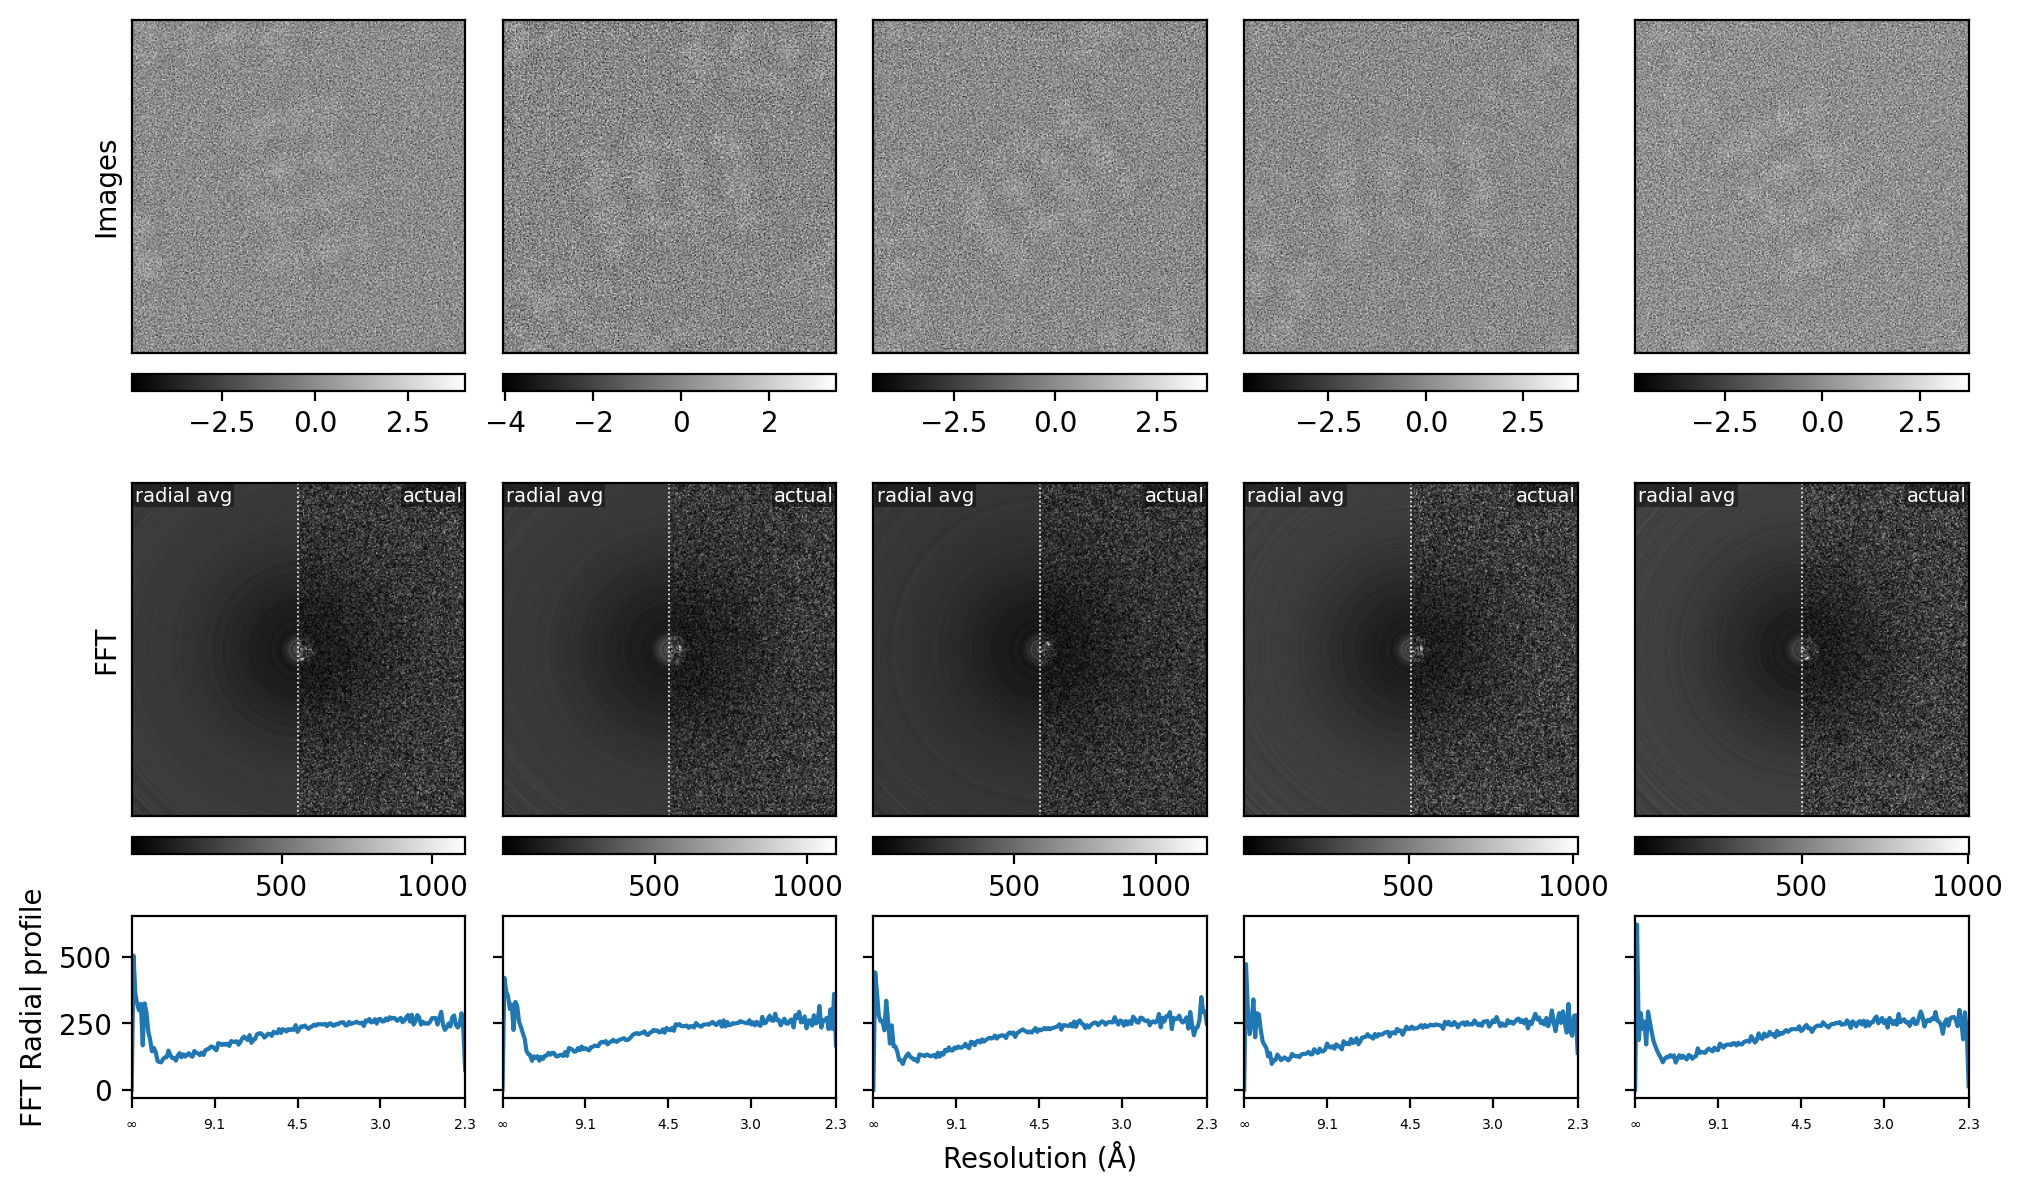

In [13]:
# normalize and flip sign
if config.normalize_particles:
    particles, means, stds = normalize_particles(images)
    particles = -particles
else:
    particles = images

plot_particle_stack(particles, pixel_size)

## Compare with experimental particles (if available)

In [14]:
with mrcfile.mmap(
    "/scratch/loh/joel/cryosparc_tutorial/CS-cryosparc-tutorial/J35/restack/batch_0_restacked.mrc"
) as mrc:
    exp = torch.as_tensor(mrc.data[indices].copy())

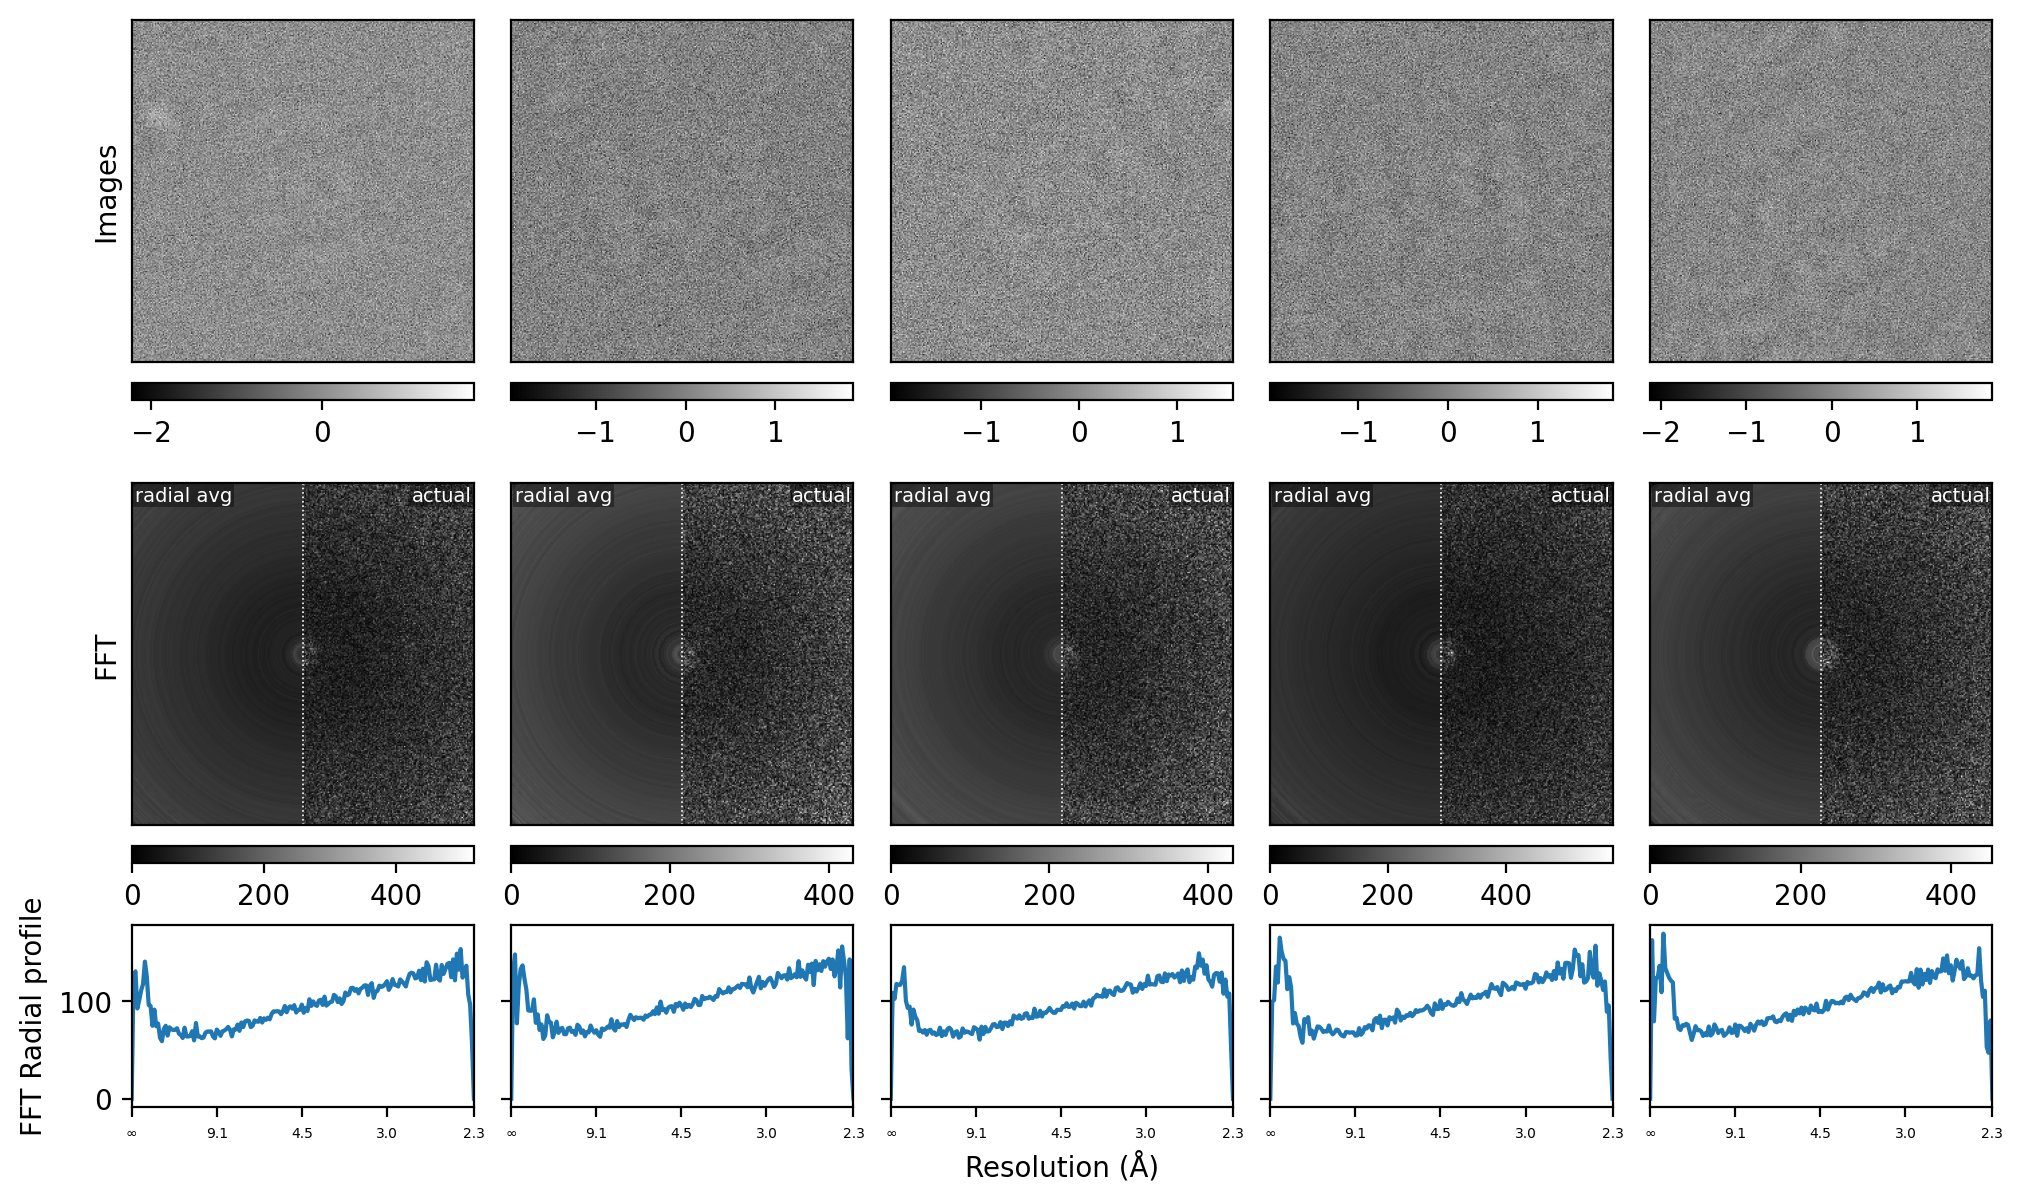

In [15]:
plot_particle_stack(exp, pixel_size)